In [1]:
import joblib
import os

os.chdir("..")
model = joblib.load("qsar/model/latest.pkl")
model.predictor.feature_importances_

c:\Users\Mikhail\miniconda3\envs\sber_hack\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


array([0.00034492, 0.        , 0.00034092, ..., 0.00035083, 0.        ,
       0.0029726 ], dtype=float32)

<BarContainer object of 2048 artists>

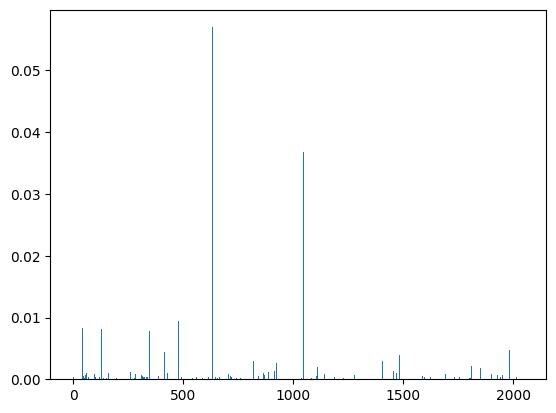

In [2]:
import matplotlib.pyplot as plt

plt.bar(range(len(model.predictor.feature_importances_)), model.predictor.feature_importances_)

In [ ]:
booster = model.predictor.get_booster()

importance = booster.get_score(importance_type="gain")  # лучший вариант

import shap
import pandas as pd


df = pd.read_csv("qsar/dataset/data_rdkit_train.csv")



In [21]:
descriptor = model.descriptor
FP = descriptor.parallel_compute_descriptor(df["smiles"].to_list())
print(FP)

[array([1, 0, 0, ..., 1, 0, 1], dtype=uint8), array([1, 0, 0, ..., 0, 0, 1], dtype=uint8), array([0, 0, 1, ..., 0, 0, 1], dtype=uint8), array([1, 0, 0, ..., 1, 0, 1], dtype=uint8), array([1, 0, 0, ..., 0, 0, 0], dtype=uint8), array([1, 0, 0, ..., 0, 0, 0], dtype=uint8), array([1, 0, 0, ..., 0, 0, 0], dtype=uint8), array([1, 0, 0, ..., 0, 0, 0], dtype=uint8), array([1, 0, 0, ..., 0, 0, 0], dtype=uint8), array([1, 0, 0, ..., 0, 0, 1], dtype=uint8), array([0, 0, 1, ..., 0, 0, 1], dtype=uint8), array([1, 0, 0, ..., 0, 0, 1], dtype=uint8), array([1, 0, 0, ..., 0, 0, 1], dtype=uint8), array([1, 0, 0, ..., 0, 0, 0], dtype=uint8), array([1, 0, 0, ..., 1, 0, 0], dtype=uint8), array([0, 0, 0, ..., 0, 0, 1], dtype=uint8), array([1, 0, 0, ..., 0, 0, 0], dtype=uint8), array([1, 0, 0, ..., 1, 0, 0], dtype=uint8), array([1, 0, 0, ..., 1, 0, 0], dtype=uint8), array([1, 0, 0, ..., 0, 0, 1], dtype=uint8), array([0, 0, 0, ..., 0, 0, 1], dtype=uint8), array([1, 0, 0, ..., 0, 0, 0], dtype=uint8), array([1,

In [29]:
import numpy as np
X = np.concatenate([np.array([fp]) for fp in FP])
X

array([[1, 0, 0, ..., 1, 0, 1],
       [1, 0, 0, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 0, 1],
       ...,
       [1, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 1, 0],
       [1, 0, 0, ..., 0, 0, 1]], dtype=uint8)

In [40]:
explainer = shap.TreeExplainer(model.predictor.get_booster(), X)
shap_values = explainer.shap_values(X)

ValueError: could not convert string to float: '[6.3216147E0]'

In [ ]:
model.predictor.get_booster()

{'name': '',
 'buildconfig': {'data': {'training_dataset_file': 'qsar/dataset/data_rdkit_train.csv',
   'input_column': 'smiles',
   'response_column': 'activity',
   'response_type': 'regression',
   'deduplication_strategy': {'name': 'KeepAllNoDeduplication'},
   'split_strategy': {'name': 'Stratified',
    'fraction': 0.2,
    'seed': 1,
    'leave_out': 0.0,
    'bins': 'fd_merge'},
   'test_dataset_file': 'qsar/dataset/data_rdkit_test.csv',
   'save_intermediate_files': False,
   'log_transform': False,
   'log_transform_base': None,
   'log_transform_negative': None,
   'log_transform_unit_conversion': None,
   'probabilistic_threshold_representation': False,
   'probabilistic_threshold_representation_threshold': None,
   'probabilistic_threshold_representation_std': None,
   'assess_modelability': False},
  'metadata': {'name': '',
   'n_splits': 5,
   'shuffle': False,
   'best_trial': 178,
   'best_value': -0.6701382010828374,
   'n_trials': 200,
   'visualization': None},
  '